# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- **Nama:** Aprido Ilham
- **Email:** aprido233@gmail.com
- **Username Dicoding:** apridoilham

## 1. Business Understanding
Jaya Jaya Institut menghadapi tingginya persentase mahasiswa putus sekolah (*dropout*). Hal ini berdampak buruk bagi reputasi institut dan mengindikasikan adanya masalah yang tidak terdeteksi pada performa mahasiswa.

### Permasalahan Bisnis
- Tingkat *dropout* yang tinggi yang merugikan institusi pendidikan.
- Tidak adanya deteksi dini yang memadai sehingga bimbingan konseling dan akademik terlambat diberikan kepada mahasiswa yang berisiko.

### Cakupan Proyek
- **Eksplorasi Data (EDA):** Mengidentifikasi faktor dominan yang menyebabkan mahasiswa *dropout* (seperti usia, beasiswa, kondisi ekonomi).
- **Pemodelan Machine Learning:** Membuat model klasifikasi untuk memprediksi probabilitas *dropout* seorang mahasiswa.
- **Implementasi:** Mendeploy model ke dalam sebuah prototipe aplikasi berbasis Streamlit dan menyusun *Business Dashboard* untuk memonitor performa mahasiswa.

## 2. Persiapan

Tahap persiapan ini bertujuan untuk memuat pustaka (*libraries*) analitik standar dan melakukan *import* data.

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib
import os

# Konfigurasi gaya visualisasi agar terlihat profesional (Prinsip Desain & Integritas Data)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Menyiapkan data yang akan digunakan

In [2]:
# Membaca dataset
df = pd.read_csv('data.csv', sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 3. Data Understanding

Pada tahap ini, kita akan mengenali data secara menyeluruh. Kita memeriksa apakah ada *missing values*, melihat distribusi target (*Status*), dan mencari pola yang mungkin tersembunyi menggunakan visualisasi yang jelas dan mematuhi prinsip desain (konsistensi warna, pelabelan, dan kemudahan dibaca).

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   int64  
 10 

/var/folders/36/6vd3mh013hxf78rbtwg405tc0000gn/T/ipykernel_90520/2930027629.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Status', palette='viridis')


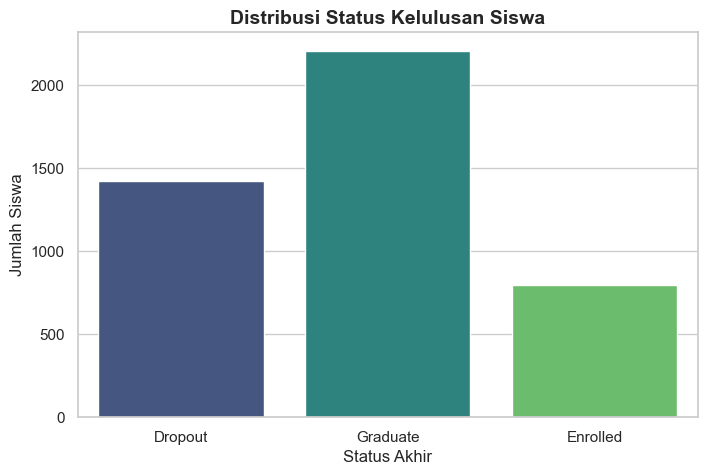

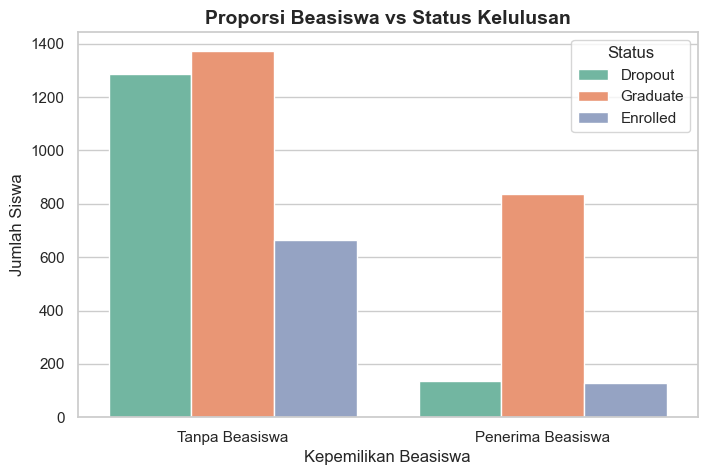

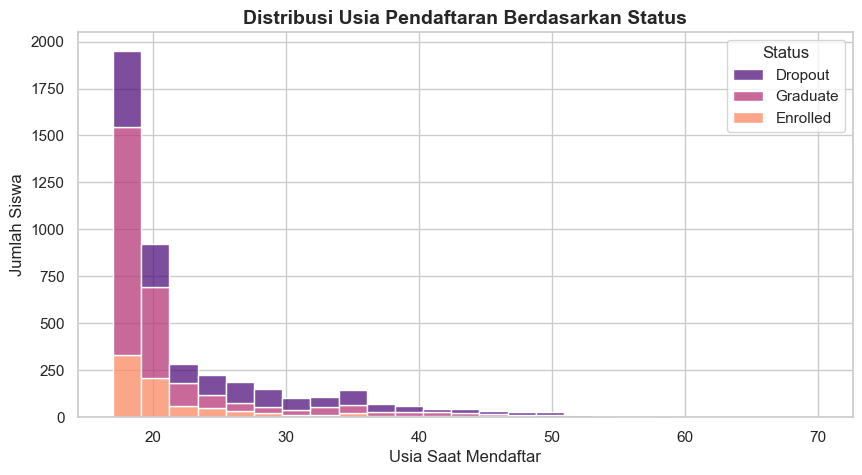

In [3]:
# Informasi dataset dan cek missing values
print(df.info())
print("\nMissing values:\n", df.isnull().sum().sum())

# 1. Distribusi Target Variabel (Status)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Status', palette='viridis')
plt.title('Distribusi Status Kelulusan Siswa', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah Siswa')
plt.xlabel('Status Akhir')
plt.show()

# 2. Analisis Pengaruh Beasiswa terhadap Dropout
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Scholarship_holder', hue='Status', palette='Set2')
plt.title('Proporsi Beasiswa vs Status Kelulusan', fontsize=14, fontweight='bold')
plt.xticks(ticks=[0, 1], labels=['Tanpa Beasiswa', 'Penerima Beasiswa'])
plt.ylabel('Jumlah Siswa')
plt.xlabel('Kepemilikan Beasiswa')
plt.legend(title='Status')
plt.show()

# 3. Distribusi Usia saat mendaftar
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Age_at_enrollment', hue='Status', multiple='stack', bins=25, palette='magma')
plt.title('Distribusi Usia Pendaftaran Berdasarkan Status', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah Siswa')
plt.xlabel('Usia Saat Mendaftar')
plt.show()

## 4. Data Preparation / Preprocessing

Karena tujuan institusi adalah mendeteksi "Dropout" sedini mungkin, kita akan mengubah klasifikasi ini menjadi *binary classification* (0 = Non-Dropout, 1 = Dropout).
Selain itu, kita memisahkan data latih dan data uji, serta melakukan *scaling* agar model tidak bias terhadap variabel dengan rentang nilai yang besar.

In [4]:
# Mengubah target variabel menjadi biner (1: Dropout, 0: Lainnya)
df['Target'] = df['Status'].apply(lambda x: 1 if x == 'Dropout' else 0)

# Memisahkan Fitur (X) dan Target (y)
X = df.drop(['Status', 'Target'], axis=1)
y = df['Target']

# Splitting data dengan proporsi 80% latih, 20% uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling numerik (Standarisasi)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Menyimpan objek scaler untuk digunakan di app Streamlit
os.makedirs('model', exist_ok=True)
joblib.dump(scaler, 'model/scaler.pkl')
print("Scaler berhasil disimpan di 'model/scaler.pkl'")


Scaler berhasil disimpan di 'model/scaler.pkl'


## 5. Modeling

Model yang dipilih adalah **Random Forest Classifier**. Alasannya:
1. Sangat kuat menghadapi data tabular yang kompleks.
2. Dapat mengatasi *class imbalance* dengan parameter `class_weight='balanced'`.
3. Memiliki fitur `feature_importances_` bawaan yang membantu kita melihat fitur mana yang paling relevan dalam menentukan *dropout* mahasiswa.

In [5]:
# Inisialisasi model Random Forest dengan class_weight balanced untuk menutupi ketidakseimbangan kelas
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Melatih model
model.fit(X_train_scaled, y_train)

# Menyimpan model
joblib.dump(model, 'model/dropout_model.pkl')
print("Model berhasil dilatih dan disimpan di 'model/dropout_model.pkl'")


Model berhasil dilatih dan disimpan di 'model/dropout_model.pkl'


## 6. Evaluation

Kita mengukur kualitas model. Dalam deteksi dini, nilai **Recall** untuk kelas Dropout (1) sangat penting. Institut ingin memastikan sebanyak mungkin siswa berisiko *dropout* berhasil dideteksi.

Accuracy: 0.880225988700565

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92       601
           1       0.88      0.72      0.79       284

    accuracy                           0.88       885
   macro avg       0.88      0.84      0.86       885
weighted avg       0.88      0.88      0.88       885



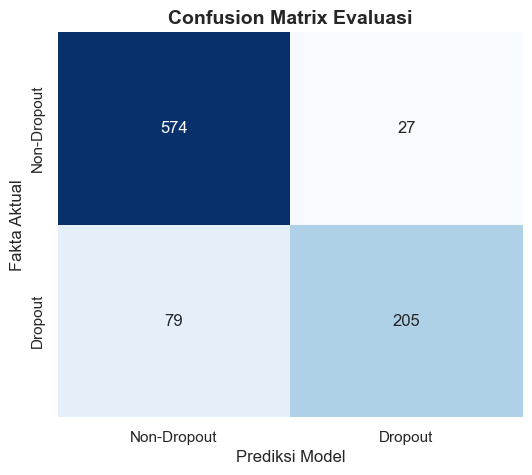

/var/folders/36/6vd3mh013hxf78rbtwg405tc0000gn/T/ipykernel_90520/2389498402.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='mako')


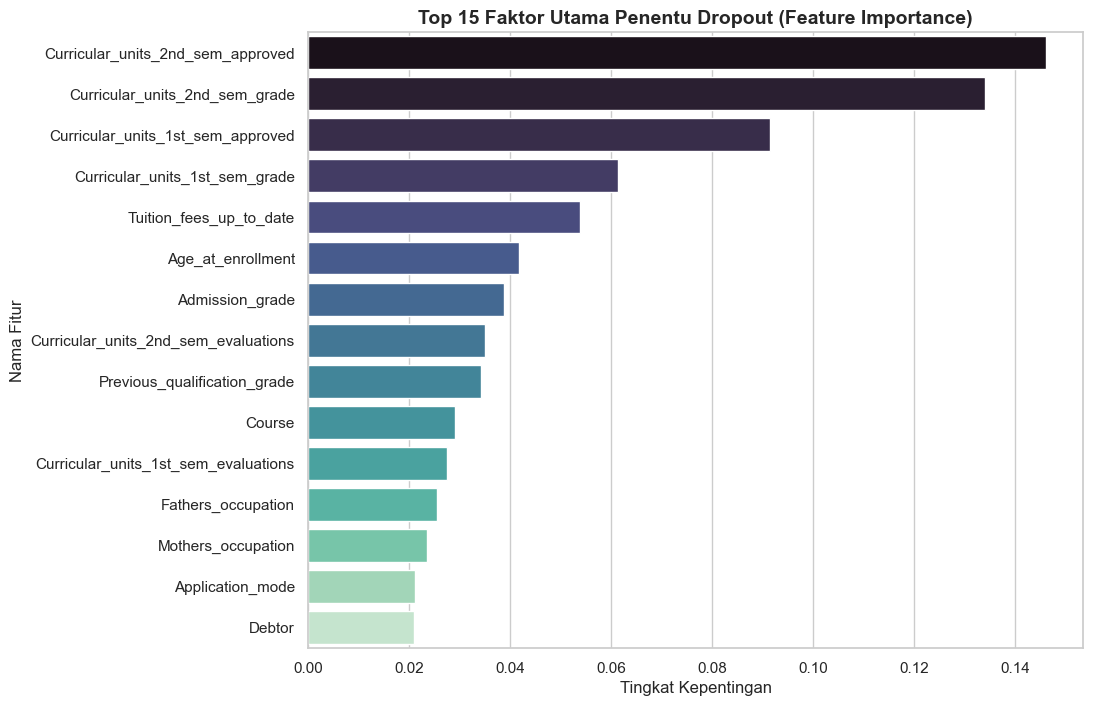

In [6]:
# Prediksi pada data test
y_pred = model.predict(X_test_scaled)

# Menampilkan metrik utama
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix Visualisasi
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Non-Dropout', 'Dropout'], yticklabels=['Non-Dropout', 'Dropout'])
plt.xlabel('Prediksi Model', fontsize=12)
plt.ylabel('Fakta Aktual', fontsize=12)
plt.title('Confusion Matrix Evaluasi', fontsize=14, fontweight='bold')
plt.show()

# Menampilkan Feature Importance
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='mako')
plt.title('Top 15 Faktor Utama Penentu Dropout (Feature Importance)', fontsize=14, fontweight='bold')
plt.xlabel('Tingkat Kepentingan')
plt.ylabel('Nama Fitur')
plt.show()
